In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:
df=pd.read_csv('Travel.csv')
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [4]:
deferer = [features for features in df.columns if df[features].dtype =='O']
for feature in deferer:
    print(df[feature].value_counts(),'\n')

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64 

Occupation
Salaried          2368
Small Business    2084
Large Business     434
Free Lancer          2
Name: count, dtype: int64 

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64 

ProductPitched
Basic           1842
Deluxe          1732
Standard         742
Super Deluxe     342
King             230
Name: count, dtype: int64 

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64 

Designation
Executive         1842
Manager           1732
Senior Manager     742
AVP                342
VP                 230
Name: count, dtype: int64 



In [5]:
df['Gender']=df['Gender'].replace('Fe Male','Female')
df['MaritalStatus']=df['MaritalStatus'].replace('Unmarried','Single')

In [6]:
df['TotalVisitor']=df['NumberOfChildrenVisiting']+df['NumberOfPersonVisiting']

In [7]:
df.drop(columns=['CustomerID','NumberOfChildrenVisiting','NumberOfPersonVisiting'],axis=1,inplace=True)

In [8]:
df

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisitor
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Single,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Single,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,NaN,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,5.0,Deluxe,4.0,Single,2.0,1,1,1,Manager,26576.0,4.0
4884,1,28.0,Company Invited,1,31.0,Salaried,Male,5.0,Basic,3.0,Single,3.0,1,3,1,Executive,21212.0,6.0
4885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4.0,Standard,4.0,Married,7.0,0,1,1,Senior Manager,31820.0,7.0
4886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,4.0,Basic,3.0,Single,3.0,0,5,0,Executive,20289.0,5.0


In [9]:
df.isnull().sum()

ProdTaken                   0
Age                       226
TypeofContact              25
CityTier                    0
DurationOfPitch           251
Occupation                  0
Gender                      0
NumberOfFollowups          45
ProductPitched              0
PreferredPropertyStar      26
MaritalStatus               0
NumberOfTrips             140
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
Designation                 0
MonthlyIncome             233
TotalVisitor               66
dtype: int64

In [10]:
null_features = [features for features in df.columns if df[features].isnull().sum()>=1]
for features in null_features:
    print(features,np.round(df[features].isnull().mean()*100,5),'%missing vlaues')

Age 4.62357 %missing vlaues
TypeofContact 0.51146 %missing vlaues
DurationOfPitch 5.13502 %missing vlaues
NumberOfFollowups 0.92062 %missing vlaues
PreferredPropertyStar 0.53191 %missing vlaues
NumberOfTrips 2.86416 %missing vlaues
MonthlyIncome 4.76678 %missing vlaues
TotalVisitor 1.35025 %missing vlaues


In [11]:
df.head(2)

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisitor
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Single,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0


In [12]:
df.Age.fillna(df.Age.median(),inplace=True)
df.TypeofContact.fillna(df.TypeofContact.mode()[0],inplace=True)
df.DurationOfPitch.fillna(df.DurationOfPitch.median(),inplace=True)
df.NumberOfFollowups.fillna(df.NumberOfFollowups.mode()[0],inplace=True)
df.PreferredPropertyStar.fillna(df.PreferredPropertyStar.mode()[0],inplace=True)
df.NumberOfTrips.fillna(df.NumberOfTrips.mode()[0],inplace=True)
df.MonthlyIncome.fillna(df.MonthlyIncome.median(),inplace=True)
df.TotalVisitor.fillna(df.TotalVisitor.mode()[0],inplace=True)

In [13]:
X=df.drop('ProdTaken',axis=1)
y=df['ProdTaken']

In [14]:
y

0       1
1       0
2       1
3       0
4       0
       ..
4883    1
4884    1
4885    1
4886    1
4887    1
Name: ProdTaken, Length: 4888, dtype: int64

In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,train_size=0.25,random_state=42)

In [16]:
numer=X.select_dtypes(exclude='object').columns
classif=X.select_dtypes(include='object').columns
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
numTrass=StandardScaler()
calsstrass=OneHotEncoder(drop='first')


In [17]:
preproc=ColumnTransformer(
    [
        ('onehotenco',calsstrass,classif),
        ('StandardScaler',numTrass,numer)
    ]
)

In [18]:
X_train=preproc.fit_transform(X_train)
X_test =preproc.transform(X_test)

In [19]:
X_train

array([[ 1.        ,  0.        ,  0.        , ..., -1.26054871,
        -0.4331843 ,  0.00585648],
       [ 0.        ,  1.        ,  0.        , ...,  0.79330532,
        -0.23138046, -0.70980531],
       [ 1.        ,  0.        ,  1.        , ...,  0.79330532,
        -0.7438665 , -0.70980531],
       ...,
       [ 1.        ,  1.        ,  0.        , ...,  0.79330532,
        -0.00405202,  0.00585648],
       [ 1.        ,  0.        ,  0.        , ..., -1.26054871,
         2.13861821, -0.70980531],
       [ 1.        ,  0.        ,  1.        , ..., -1.26054871,
         0.6561975 ,  0.72151827]])

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 

In [21]:
def model_evel(true,predict):
    acc_sc = accuracy_score(true,predict)
    f1_scor = f1_score(true,predict)
    prec_scor = precision_score(true,predict)
    recall_sc = recall_score(true,predict)
    roc_scoe = roc_auc_score(true,predict)
    return acc_sc,f1_scor,prec_scor,recall_sc,roc_scoe


In [22]:
models ={
    'LogisticRegression':LogisticRegression(),
    'KNeighborsClassifier':KNeighborsClassifier(),
    'DecisionTreeClassifier':DecisionTreeClassifier(),
    'GradientBoostingClassifier':GradientBoostingClassifier(),
    'RandomforestClassifer':RandomForestClassifier(),
    'AdaBoostClassifier':AdaBoostClassifier(),
    'XGclassifier':XGBClassifier()
    
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    Y_train_pred =model.predict(X_train)
    Y_test_pred = model.predict(X_test)

    trainacc,trainf1_scor,trainprec_scor,trainrecall_sc,trainroc_scoe=model_evel(y_train,Y_train_pred)
    testacc_sc,testf1_scor,testprec_scor,testrecall_sc,testroc_scoe=model_evel(y_test,Y_test_pred)
 
    print(list(models.keys())[i])
    print('Model preformance Training Prediction ')
    print('accuracy:{:.4f}'.format(trainacc))
    print('F1 score:{:.4f}'.format(trainf1_scor))
    print('precision:{:.4f}'.format(trainprec_scor))
    print('recall score:{:.4f}'.format(trainrecall_sc))
    print('roc_auc_score:{:.4f}'.format(trainroc_scoe))
    
    print('----------------------------------------------------')

    print('Model preformance Test Prediction ')
    print('accuracy:{:.4f}'.format(testacc_sc))
    print('F1 score:{:.4f}'.format(testf1_scor))
    print('precision:{:.4f}'.format(testprec_scor))
    print('recall score:{:.4f}'.format(testrecall_sc))
    print('roc_auc_score:{:.4f}'.format(testroc_scoe))

    print('====================================================')
    print('\n')



LogisticRegression
Model preformance Training Prediction 
accuracy:0.8347
F1 score:0.3399
precision:0.6190
recall score:0.2342
roc_auc_score:0.6011
----------------------------------------------------
Model preformance Test Prediction 
accuracy:0.8478
F1 score:0.4294
precision:0.6796
recall score:0.3139
roc_auc_score:0.6404


KNeighborsClassifier
Model preformance Training Prediction 
accuracy:0.8936
F1 score:0.6221
precision:0.8770
recall score:0.4820
roc_auc_score:0.7335
----------------------------------------------------
Model preformance Test Prediction 
accuracy:0.8421
F1 score:0.4062
precision:0.6471
recall score:0.2960
roc_auc_score:0.6300


DecisionTreeClassifier
Model preformance Training Prediction 
accuracy:1.0000
F1 score:1.0000
precision:1.0000
recall score:1.0000
roc_auc_score:1.0000
----------------------------------------------------
Model preformance Test Prediction 
accuracy:0.8044
F1 score:0.4724
precision:0.4652
recall score:0.4798
roc_auc_score:0.6783


GradientBo

In [23]:

RandomForestparems={
   'n_estimators': [100,200,30,400,500,600,700,1500,2000],
   'criterion': ['gini', 'entropy', 'log_loss'] ,
   'max_depth':[1,2,3,4,5,6,7],
   'min_samples_split': [0.1,0.02,0.3,0.1,0.21,1.0],
    'min_samples_leaf':[ 1,2,3,4,5,6],
    'max_features': [1,2,3,4,5,6]   
}
Addaboost_parems={
    'n_estimators':[10,20,30,40,50,60,100],
    'learning_rate':[0.1,0.2,0.3,0.25,1.0],
    'algorithm': ['SAMME', 'SAMME.R']   
}

gradientboost_parem ={
    'loss': ['log_loss', 'deviance', 'exponential'] ,
    'learning_rate': [0.1,0.2,0.3,0.25,1.0],
    'n_estimators': [100,200,300,500],
    'subsample': [0.1,0.2,0.3,0.4],
    'criterion': ['friedman_mse', 'squared_error'] 
    
}
Xg_parem={
    'learning_rate':[0.1,0.2,0.01],
    'max_depth':[5,6,8,10],
    'n_estimators':[100,300,500],
    'colsample_bytree':[0.1,0.5,0.8,1,2]
}


In [24]:
models2=[
    ('GradientBoostingClassifier',GradientBoostingClassifier(),gradientboost_parem),
    ('RandomforestClassifer',RandomForestClassifier(),RandomForestparems,),
    ('AdaBoostClassifier',AdaBoostClassifier(),Addaboost_parems),
    ('XGBClassifier',XGBClassifier(),Xg_parem)
]

In [25]:
models2
from sklearn.model_selection import RandomizedSearchCV


In [26]:
model_parem={}
for name,model,parem in models2:
    random = RandomizedSearchCV(estimator=model,
                                param_distributions=parem,
                                cv=3,
                                n_iter=100,
                                verbose=3,
                                n_jobs=-1)
    random.fit(X_train,y_train)
    model_parem[name]=random.best_params_


for model_name in model_parem:
    print(f'---------------best parems {model_name}------------------')
    print(model_parem[model_name],'\n')


Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 70 candidates, totalling 210 fits
Fitting 3 folds for each of 100 candidates, totalling 300 fits
---------------best parems GradientBoostingClassifier------------------
{'subsample': 0.4, 'n_estimators': 200, 'loss': 'exponential', 'learning_rate': 0.25, 'criterion': 'friedman_mse'} 

---------------best parems RandomforestClassifer------------------
{'n_estimators': 100, 'min_samples_split': 0.02, 'min_samples_leaf': 2, 'max_features': 6, 'max_depth': 6, 'criterion': 'log_loss'} 

---------------best parems AdaBoostClassifier------------------
{'n_estimators': 30, 'learning_rate': 1.0, 'algorithm': 'SAMME'} 

---------------best parems XGBClassifier------------------
{'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1} 



In [27]:
new_models = {
    'GradientBoostingClassifier': GradientBoostingClassifier(subsample = 0.3, n_estimators = 500, loss = 'exponential', learning_rate= 0.1, criterion = 'friedman_mse'),
    'RandomforestClassifer':RandomForestClassifier(n_estimators = 600, min_samples_split =0.02, min_samples_leaf =6, max_features =5, max_depth = 7, criterion = 'log_loss'),
    'AdaBoostClassifier':AdaBoostClassifier(n_estimators = 30, learning_rate = 1.0, algorithm = 'SAMME'),
    'XGBClassifier':XGBClassifier(n_estimators=300, max_depth =8, learning_rate = 0.1, colsample_bytree =1)
}


In [28]:
print(f'Model Tranning with best parems {model_parem.keys()}\n{model_parem.values()}')
for i in range(len(list(new_models))):
    model = list(new_models.values())[i]
    model.fit(X_train,y_train)
    Y_train_pred =model.predict(X_train)
    Y_test_pred = model.predict(X_test)

    trainacc,trainf1_scor,trainprec_scor,trainrecall_sc,trainroc_scoe=model_evel(y_train,Y_train_pred)
    testacc_sc,testf1_scor,testprec_scor,testrecall_sc,testroc_scoe=model_evel(y_test,Y_test_pred)
 
    print(list(new_models.keys())[i])
    print('Model preformance Training Prediction ')
    print('accuracy:{:.4f}'.format(trainacc))
    print('F1 score:{:.4f}'.format(trainf1_scor))
    print('precision:{:.4f}'.format(trainprec_scor))
    print('recall score:{:.4f}'.format(trainrecall_sc))
    print('roc_auc_score:{:.4f}'.format(trainroc_scoe))
    
    print('----------------------------------------------------')

    print('Model preformance Test Prediction ')
    print('accuracy:{:.4f}'.format(testacc_sc))
    print('F1 score:{:.4f}'.format(testf1_scor))
    print('precision:{:.4f}'.format(testprec_scor))
    print('recall score:{:.4f}'.format(testrecall_sc))
    print('roc_auc_score:{:.4f}'.format(testroc_scoe))

    print('====================================================')
    print('\n')




    

Model Tranning with best parems dict_keys(['GradientBoostingClassifier', 'RandomforestClassifer', 'AdaBoostClassifier', 'XGBClassifier'])
dict_values([{'subsample': 0.4, 'n_estimators': 200, 'loss': 'exponential', 'learning_rate': 0.25, 'criterion': 'friedman_mse'}, {'n_estimators': 100, 'min_samples_split': 0.02, 'min_samples_leaf': 2, 'max_features': 6, 'max_depth': 6, 'criterion': 'log_loss'}, {'n_estimators': 30, 'learning_rate': 1.0, 'algorithm': 'SAMME'}, {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1}])
GradientBoostingClassifier
Model preformance Training Prediction 
accuracy:0.9771
F1 score:0.9330
precision:0.9949
recall score:0.8784
roc_auc_score:0.9387
----------------------------------------------------
Model preformance Test Prediction 
accuracy:0.8568
F1 score:0.5333
precision:0.6579
recall score:0.4484
roc_auc_score:0.6982


RandomforestClassifer
Model preformance Training Prediction 
accuracy:0.8453
F1 score:0.2759
precision:0.9231
rec

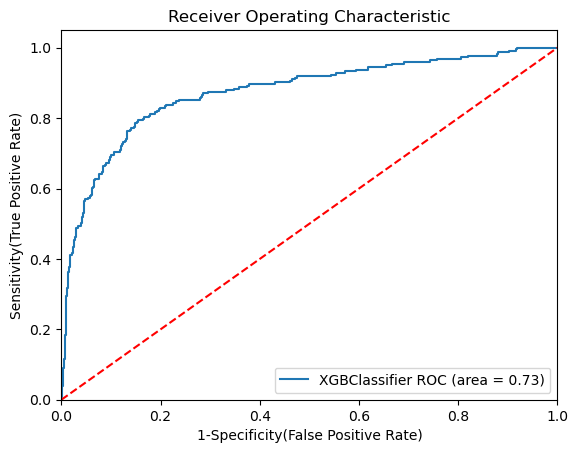

In [29]:
from sklearn.metrics import roc_auc_score,roc_curve
plt.plot()

modela =[
    {
        'Label':'XGBClassifier',
        'Model':XGBClassifier(n_estimators=300, max_depth =8, learning_rate = 0.1, colsample_bytree =1),
        'auc_score':0.7311
    }
]
for algo in modela:
    model = algo['Model']
    model.fit(X_train,y_train)
    fpr ,Tpr,thresshold = roc_curve(y_test,model.predict_proba(X_test)[:,1])
    plt.plot(fpr,Tpr,label='%s ROC (area = %0.2f)' % (algo['Label'], algo['auc_score']))
plt.plot([0,1],[0,1],'r--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig("aucadna.png")
plt.show() 